<a href="https://colab.research.google.com/github/v-c-sch/DSF-DCBP-Rep.-SCHV/blob/main/CodingTask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Science Fundamentals for DCBP, S. Haug, University of Bern

# Coding Task 1: Learn the Polymer Data

- Submission format: notebook only
- Work style: individual
- Focus: pandas dataframe basics on Kaggle polymer data
- Main data file: `data/train.csv`
- Optional bonus: install RDKit to extract additional features

- **Deadline**: Send your solution notebook per email to Sigve by 2022-03-18 17:00
- Estimated effort: 2-5 hours (if you don't progress after 2 hours of trying, search for help, ChatGPT, Google, colleagues, course tutor)
- Data on Ilias: `Data` folder. Download the zip file and extract all the files inside into a `data` folder on your local machine or copy it on Colab

- **HINTS**: You will find parts where the code is missing and three dots are present (...). You need to replace it with your code. Do not try to implement everything inside a function right away, implement it outside, in a code cell and only when it works try adding it inside the function. The use of functions is suggested for best practice, but if the code does what it is supposed to do you will not lose points for having it outside of functions.

## Points (12.5 total)

1. **CT1.1** Load and inspect main files (2.0)
2. **CT1.2** Missing values and target availability plot (2.0)
3. **CT1.3** Build clean FFV table and save it (2.5)
4. **CT1.4** Add basic SMILES features and save (3.0)
5. **CT1.5** Fixed train/valid split and save (2.0)
6. **CT1.6** Short written interpretation (1.0)

Optional bonus: RDKit descriptors (+1.5 max)


In [52]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/DSF")
ARTIFACT_DIR = Path("/content/drive/MyDrive/DSF/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["Tg", "FFV", "Tc", "Density", "Rg"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CT1.1 Load and inspect the main files (2.0 pts)

Load:
- `train.csv`
- `test.csv`
- `sample_submission.csv`

Show for each file:
1. Number of rows and columns
2. Column names
3. First 5 rows

Implement this function:
- `load_main_tables(data_dir)`


In [53]:
def load_main_tables(DATA_DIR):
    """Load train/test/sample_submission tables and return them in a dict.

    Expected keys:
    - "train"
    - "test"
    - "sample_submission"
    """
    base = Path(DATA_DIR)
    tables = {
        "train": pd.read_csv(base / "train.csv"),
        "test": pd.read_csv(base / "test.csv"),
        "sample_submission": pd.read_csv(base / "sample_submission.csv"),
    }
    return tables

In [54]:
# Run after implementing load_main_tables.
tables = load_main_tables(DATA_DIR)

for name, df in tables.items():
    print(f"\n=== {name} ===")
    print(f"shape: {df.shape}")
    print("columns:", list(df.columns))
    display(df.head())



=== train ===
shape: (7973, 7)
columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']


,id,SMILES,Tg,FFV,Tc,Density,Rg
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN



=== test ===
shape: (3, 2)
columns: ['id', 'SMILES']


,id,SMILES
0,1109053969,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...
1,1422188626,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...
2,2032016830,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...



=== sample_submission ===
shape: (3, 6)
columns: ['id', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']


,id,Tg,FFV,Tc,Density,Rg
0,1109053969,0,0,0,0,0
1,1422188626,0,0,0,0,0
2,2032016830,0,0,0,0,0


## CT1.2 Missing values and availability plot (2.0 pts)

Using `train.csv`, compute missing values for targets:
- `Tg`, `FFV`, `Tc`, `Density`, `Rg`

Create one bar plot of available values per target.

Implement this function:
- `missing_value_report(train_df)`


In [55]:
def missing_value_report(train_df):
    """Return a report with columns: target, total, missing, available."""
    total = len(train_df)
    rows = []

    for col in TARGET_COLS:
        missing = train_df[col].isna().sum()
        available = total - missing
        rows.append({
            "target": col,
            "total": total,
            "missing": missing,
            "available": available,
        })

    return pd.DataFrame(rows)


,target,total,missing,available
0,Tg,7973,7462,511
1,FFV,7973,943,7030
2,Tc,7973,7236,737
3,Density,7973,7360,613
4,Rg,7973,7359,614


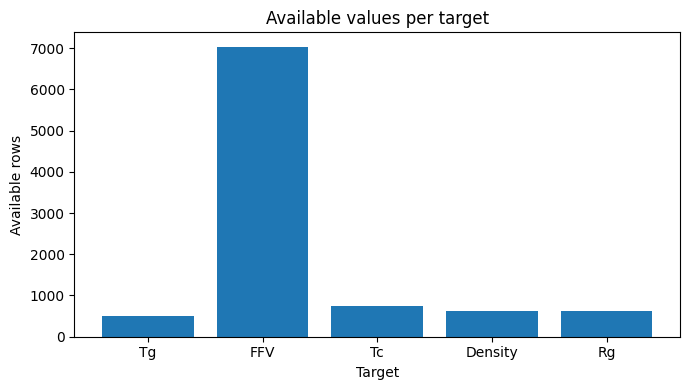

In [56]:
# Run this after implementing missing_value_report.
train_df = tables["train"]
report = missing_value_report(train_df)
display(report)

plt.figure(figsize=(7, 4))
plt.bar(report["target"], report["available"])
plt.title("Available values per target")
plt.xlabel("Target")
plt.ylabel("Available rows")
plt.tight_layout()
plt.show()


## CT1.3 Build one clean FFV table (2.5 pts)

From `train.csv`, keep only rows where `FFV` is not missing.

Keep only columns:
- `id`
- `SMILES`
- `FFV`

Save as:
- `artifacts/ffv_clean.csv`

Implement this function:
- `build_ffv_clean(train_df)`


In [57]:
def build_ffv_clean(train_df):
    """Return a clean FFV dataframe with columns id, SMILES, FFV."""
    ffv_df = train_df.loc[train_df["FFV"].notna(), ["id", "SMILES", "FFV"]].copy()
    return ffv_df


In [58]:
# Run after implementing build_ffv_clean.
ffv_clean = build_ffv_clean(train_df)
display(ffv_clean.head())
print("ffv_clean shape:", ffv_clean.shape)

ffv_clean_path = ARTIFACT_DIR / "ffv_clean.csv"
ffv_clean.to_csv(ffv_clean_path, index=False)
print("Saved:", ffv_clean_path)


,id,SMILES,FFV
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470


ffv_clean shape: (7030, 3)
Saved: /content/drive/MyDrive/DSF/artifacts/ffv_clean.csv


## CT1.4 Add basic SMILES features (no regex) (3.0 pts)

Create these simple features with basic string methods only:
- `smiles_len`
- `count_star` (`*`)
- `count_C`
- `count_O`
- `count_N`
- `count_equal` (`=`)

Save as:
- `artifacts/ffv_features_basic.csv`

Implement this function:
- `add_basic_smiles_features(ffv_df)`


In [59]:
def add_basic_smiles_features(ffv_df):
    """Add simple string-count features to FFV dataframe."""
    out = ffv_df.copy()

    out["smiles_len"] = out["SMILES"].str.len()
    out["count_star"] = out["SMILES"].str.count(r"\*")
    out["count_C"] = out["SMILES"].str.count("C")
    out["count_O"] = out["SMILES"].str.count("O")
    out["count_N"] = out["SMILES"].str.count("N")
    out["count_equal"] = out["SMILES"].str.count("=")

    return out

In [60]:
# Run after implementing add_basic_smiles_features.
ffv_features = add_basic_smiles_features(ffv_clean)
display(ffv_features.head())

ffv_features_path = ARTIFACT_DIR / "ffv_features_basic.csv"
ffv_features.to_csv(ffv_features_path, index=False)
print("Saved:", ffv_features_path)


,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645,26,2,9,2,0,1
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410,82,2,19,0,2,0
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860,134,2,14,9,0,7
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324,79,2,4,0,2,0
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470,118,2,30,12,4,4


Saved: /content/drive/MyDrive/DSF/artifacts/ffv_features_basic.csv


## CT1.5 Fixed train/validation split (2.0 pts)

Create one reproducible 80/20 split with `random_state=42`.

Add a new column `split` with values:
- `train`
- `valid`

Save as:
- `artifacts/ffv_ready_split.csv`

Implement this function:
- `make_split(df, valid_size=0.2, seed=42) -> pd.DataFrame`


In [61]:
def make_split(df, valid_size=0.2, seed=42):
    """Return dataframe with a reproducible split column: train/valid."""
    rng = np.random.default_rng(seed)
    out = df.copy()

    n = len(out)
    valid_n = int(round(n * valid_size))
    valid_idx = rng.choice(out.index, size=valid_n, replace=False)

    out["split"] = "train"
    out.loc[valid_idx, "split"] = "valid"

    return out

In [62]:
# Run this after implementing make_split.
ffv_ready_split = make_split(ffv_features, valid_size=0.2, seed=42)
display(ffv_ready_split.head())
print(ffv_ready_split["split"].value_counts())

ffv_ready_split_path = ARTIFACT_DIR / "ffv_ready_split.csv"
ffv_ready_split.to_csv(ffv_ready_split_path, index=False)
print("Saved:", ffv_ready_split_path)


,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal,split
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645,26,2,9,2,0,1,train
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410,82,2,19,0,2,0,train
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860,134,2,14,9,0,7,train
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324,79,2,4,0,2,0,train
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470,118,2,30,12,4,4,train


split
train    5624
valid    1406
Name: count, dtype: int64
Saved: /content/drive/MyDrive/DSF/artifacts/ffv_ready_split.csv


## CT1.6 Short written interpretation (1.0 pt)

Answer in 3-6 sentences:

**1. Which target has the most data?**

FFV has the most available data among the target variables. This means it has the fewest missing values compared to the others. Therefore, it provides the largest usable dataset.

**2. Why is FFV a good first target for this course?**

FFV is a good first target because having more data makes analysis more reliable. It reduces the need to handle many missing values. This allows us to focus on learning data processing and modeling steps more effectively.

**3. Which one basic SMILES feature might be useful later, and why?**

One useful basic SMILES feature is smiles_len. It measures the length of the molecular representation string. Longer SMILES strings can indicate more complex molecules, which may influence FFV.

## Optional bonus (+1.5 max): RDKit descriptors

- Install RDKit in your environment.
- Use the cell below to add 2-3 descriptors (for example `MolWt`, `NumValenceElectrons`, `TPSA`) and save:
    - `artifacts/ffv_features_rdkit.csv`
- Explain in few sentences what they represent.

In [63]:
!pip install rdkit

from rdkit import Chem
from rdkit.Chem import Descriptors

def _rdkit_descriptors(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan, np.nan, np.nan
    return (
        Descriptors.MolWt(mol),
        Descriptors.NumValenceElectrons(mol),
        Descriptors.TPSA(mol),
    )

rdkit_df = ffv_ready_split.copy()

rdkit_values = rdkit_df["SMILES"].apply(_rdkit_descriptors)

rdkit_df[["MolWt", "NumValenceElectrons", "TPSA"]] = pd.DataFrame(
    rdkit_values.tolist(),
    index=rdkit_df.index
)

rdkit_path = ARTIFACT_DIR / "ffv_features_rdkit.csv"
rdkit_df.to_csv(rdkit_path, index=False)

print("Saved:", rdkit_path)


Saved: /content/drive/MyDrive/DSF/artifacts/ffv_features_rdkit.csv


## Test cases and checks

Run this cell only after you finish all required functions.


In [66]:
# 1) train table loaded correctly
assert "train" in tables, "Missing 'train' in tables dict"
assert len(tables["train"]) == 7973, "train.csv should have 7973 rows"

# 2) FFV non-missing rows
assert ffv_clean.shape[0] == 7030, "FFV non-missing rows should be 7030"

# 3) ffv_clean columns
assert list(ffv_clean.columns) == ["id", "SMILES", "FFV"], "ffv_clean columns must be id, SMILES, FFV"

# 4) feature columns exist and are numeric
feature_cols = ["smiles_len", "count_star", "count_C", "count_O", "count_N", "count_equal"]
for col in feature_cols:
    assert col in ffv_features.columns, f"Missing feature column: {col}"
    assert pd.api.types.is_numeric_dtype(ffv_features[col]), f"Feature column {col} must be numeric"

# 5) split column exists and is reproducible
assert "split" in ffv_ready_split.columns, "Missing split column"
assert set(ffv_ready_split["split"].unique()) <= {"train", "valid"}, "split must contain only train/valid"
recheck = make_split(ffv_features, valid_size=0.2, seed=42)
assert recheck["split"].equals(ffv_ready_split["split"]), "Split is not reproducible with seed=42"

# 6) output files exist and are reloadable
required_files = [
    ARTIFACT_DIR / "ffv_clean.csv",
    ARTIFACT_DIR / "ffv_features_basic.csv",
    ARTIFACT_DIR / "ffv_ready_split.csv",
]
for path in required_files:
    assert path.exists(), f"Missing output file: {path}"
    _tmp = pd.read_csv(path)
    assert len(_tmp) > 0, f"Output file is empty: {path}"

print("All required checks passed.")


All required checks passed.
